In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from BCI2000Tools.FileReader import bcistream

# **Simply list the states found in the file**

In [4]:
# Change this to your .dat file path

'''
Load the BCI2000 .dat recording and list every state stored in the file.
'''

from pathlib import Path
from BCI2000Tools.FileReader import bcistream

DAT_PATH = Path(r"C:\Users\gabri\Desktop\joystick_test_env\python_da\01S001R15.dat")

stream = bcistream(str(DAT_PATH))

state_names = list(stream.statedefs.keys())

print(f"Found {len(state_names)} states:\n")

for state in state_names:
    print(state)

Found 43 states:

PreStimulusTime
PresentationRequested
PresentationDisplayed
PresentationTime
PresentationFrame
AudioBufferTime
AudioPresentationTime
CursorX
CursorY
TaskPhase
TaskCondition
TaskBlockType
TargetAngle
TargetX
TargetY
TaskBlock
TaskTrial
MovementStarted
TargetHit
ReactionTimeMs
MovementTimeMs
TotalTimeMs
Running
Notes
VideoStimulusFrame
JoystickXpos
JoystickYpos
JoystickZpos
JoystickButtons1
JoystickButtons2
JoystickButtons3
JoystickButtons4
JoystickButtons9
JoystickButtons10
Recording
SourceTime
StimulusTime
SourceChannel1
FilePart
__pad0
__pad1
__pad2
__pad3


In [5]:
'''
Decode every state across the full recording and store them
in a pandas DataFrame for easier exploration.
'''

import numpy as np
import pandas as pd

_, states = stream.decode(
    nsamp="all",
    states=state_names
)

states_df = pd.DataFrame({
    name: np.asarray(states[name]).ravel()
    for name in state_names
})

print(f"Samples: {len(states_df):,}")
print(f"States:  {len(states_df.columns)}")

display(states_df.head())

Samples: 1,371,776
States:  43


,PreStimulusTime,PresentationRequested,PresentationDisplayed,PresentationTime,PresentationFrame,AudioBufferTime,AudioPresentationTime,CursorX,CursorY,TaskPhase,...,JoystickButtons10,Recording,SourceTime,StimulusTime,SourceChannel1,FilePart,__pad0,__pad1,__pad2,__pad3
0,0,0,0,0,0,0,0,512,512,0,...,0,1,54296,0,2147483728,1,0,0,0,2046820352
1,0,0,0,0,0,0,0,512,512,0,...,0,1,54296,0,2147483702,1,0,0,0,2785017856
2,0,0,0,0,0,0,0,512,512,0,...,0,1,54296,0,2147483775,1,0,0,0,0
3,0,0,0,0,0,0,0,512,512,0,...,0,1,54296,0,2147483798,1,0,0,0,3791650816
4,0,0,0,0,0,0,0,512,512,0,...,0,1,54296,0,2147483662,1,0,0,0,805306368


# **Which states contain meaningful information**

Also ID empty or null states

In [6]:
'''
Find which BCI2000 states contain meaningful data.

A state is considered populated if it contains at least one
value that is not 0 and not NaN.
'''

populated_states = []
empty_states = []

for state in states_df.columns:
    values = states_df[state]

    has_data = values.notna().any() and (values.fillna(0) != 0).any()

    if has_data:
        populated_states.append(state)
    else:
        empty_states.append(state)

print("POPULATED STATES:")
for state in populated_states:
    print(state)

print("\nEMPTY / ALL-ZERO STATES:")
for state in empty_states:
    print(state)

POPULATED STATES:
PreStimulusTime
PresentationRequested
PresentationDisplayed
PresentationTime
PresentationFrame
AudioBufferTime
AudioPresentationTime
CursorX
CursorY
TaskPhase
TaskCondition
TaskBlockType
TargetAngle
TargetX
TargetY
TaskBlock
TaskTrial
MovementStarted
TargetHit
ReactionTimeMs
MovementTimeMs
TotalTimeMs
Running
VideoStimulusFrame
JoystickXpos
JoystickYpos
Recording
SourceTime
StimulusTime
SourceChannel1
FilePart
__pad3

EMPTY / ALL-ZERO STATES:
Notes
JoystickZpos
JoystickButtons1
JoystickButtons2
JoystickButtons3
JoystickButtons4
JoystickButtons9
JoystickButtons10
__pad0
__pad1
__pad2


# **Deep dive into a specific state**

State: TaskPhase
Samples: 1,371,776
Min: 0
Max: 6
Unique values: 7

Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


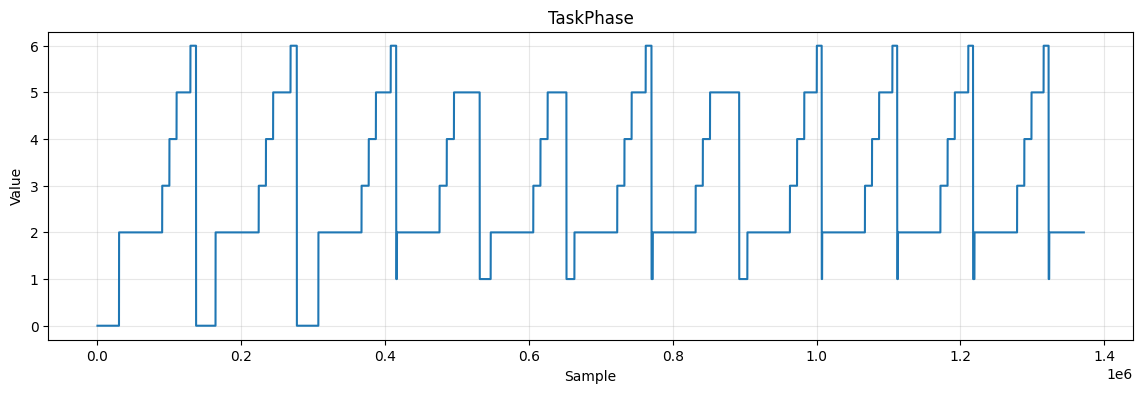

In [8]:
'''
Inspect one specific BCI2000 state in detail.

Change STATE_TO_VIEW to whichever state you want to inspect.
'''

import matplotlib.pyplot as plt

#HERE
STATE_TO_VIEW = "TaskPhase"

values = states_df[STATE_TO_VIEW]

print(f"State: {STATE_TO_VIEW}")
print(f"Samples: {len(values):,}")
print(f"Min: {values.min()}")
print(f"Max: {values.max()}")
print(f"Unique values: {values.nunique()}")

if values.nunique() <= 30:
    print(f"\nValues: {sorted(values.dropna().unique())}")

plt.figure(figsize=(14, 4))
plt.plot(values)

plt.title(STATE_TO_VIEW)
plt.xlabel("Sample")
plt.ylabel("Value")
plt.grid(alpha=0.3)

plt.show()